# Student Exam Performance — Exploratory & Comparative Analysis

## Project Overview

This dataset contains **6,607 students** with **20 features** covering academic habits, lifestyle choices, and socio-economic background. The target variable is `Exam_Score` — the student's final exam grade.

**Objective:** Explore the relationships between student factors and exam performance, verify hypotheses with statistical tests, and conclude with at least 7 actionable insights.

**Analysis Type:** Exploratory Data Analysis (EDA) + Comparative Data Analysis (CDA)

**Scope:**
- Inspect and understand the dataset structure
- Form and explore hypotheses about what drives exam scores
- Use statistical tests to verify or reject those hypotheses
- Conclude with key insights


## 1. Setup

Install `kagglehub` if not already available, then import all required libraries.


In [1]:
import subprocess
subprocess.run(["pip", "install", "kagglehub", "-q"], check=True)
print("kagglehub ready!")

kagglehub ready!


In [2]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import kagglehub

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

c:\Users\RAFA\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading & Quick Validation

Download the dataset directly from Kaggle and run immediate sanity checks.
> **Note:** First-time use requires a Kaggle API key at `~/.kaggle/kaggle.json`.


In [3]:
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Downloaded to:", path)
print("File:", csv_file)
print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())

100%|██████████| 93.9k/93.9k [00:00<00:00, 163kB/s]

Extracting files...
Downloaded to: C:\Users\RAFA\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1
File: StudentPerformanceFactors.csv
Shape: (6607, 20)

Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [4]:
print("Data types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Data types:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Each row is one student. We can already see a mix of numerical columns (like `Hours_Studied`, `Exam_Score`) and categorical ones (like `School_Type`, `Parental_Involvement`).

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Basic statistics:")
df.describe()

Missing values per column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Basic statistics:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


**Validation findings:**
- We check for any missing values that would need handling before analysis.
- The `describe()` output gives us the range and spread of all numerical features.
- `Exam_Score` is our target — its mean and spread give us a baseline to compare groups against.


## 3. Hypotheses

Before exploring the data, we state our assumptions upfront. This prevents us from cherry-picking results after seeing the data.

| # | Hypothesis |
|---|---|
| H1 | Students who study more hours per week score higher on exams |
| H2 | Higher attendance rate is associated with better exam scores |
| H3 | Students who sleep more perform better than those who sleep less |
| H4 | Students with high motivation level score higher than low motivation students |
| H5 | Students in private schools outperform those in public schools |
| H6 | Higher parental involvement is associated with better exam scores |
| H7 | Students who attend tutoring sessions score higher than those who don't |


## 4. Exploratory Data Analysis (EDA)

We start by understanding the distributions of key variables before comparing groups.

### 4.1 Target Variable — Exam Score Distribution

Understanding the shape of `Exam_Score` tells us whether it's normally distributed, skewed, or has outliers.

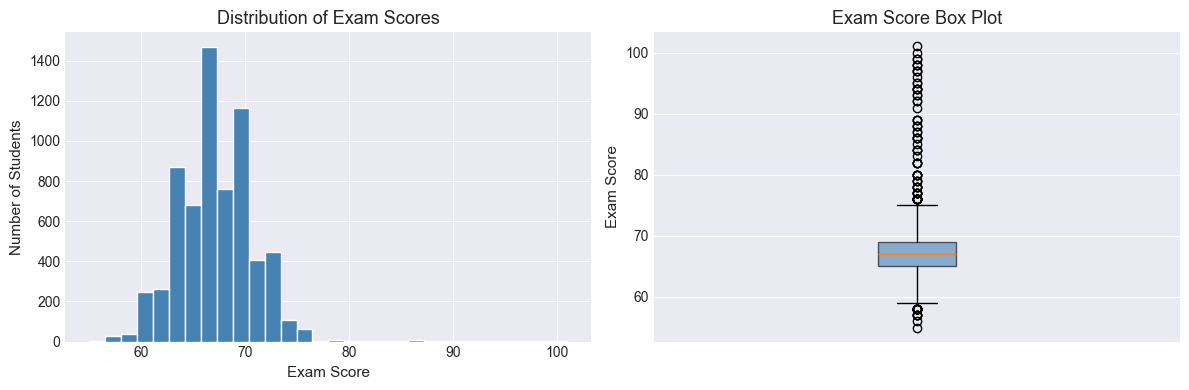

Mean  : 67.24
Median: 67.00
Std   : 3.89
Min   : 55.00
Max   : 101.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Exam Scores', fontsize=13)
axes[0].set_xlabel('Exam Score', fontsize=11)
axes[0].set_ylabel('Number of Students', fontsize=11)

axes[1].boxplot(df['Exam_Score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Exam Score Box Plot', fontsize=13)
axes[1].set_ylabel('Exam Score', fontsize=11)
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"Mean  : {df["Exam_Score"].mean():.2f}")
print(f"Median: {df["Exam_Score"].median():.2f}")
print(f"Std   : {df["Exam_Score"].std():.2f}")
print(f"Min   : {df["Exam_Score"].min():.2f}")
print(f"Max   : {df["Exam_Score"].max():.2f}")

The histogram and box plot reveal the overall spread of exam scores. If the distribution is roughly normal, parametric tests (t-test, ANOVA) are appropriate for our hypothesis testing.

### 4.2 Numerical Features Distribution

We look at the distribution of all numerical features to spot skewness, outliers, or unusual patterns.

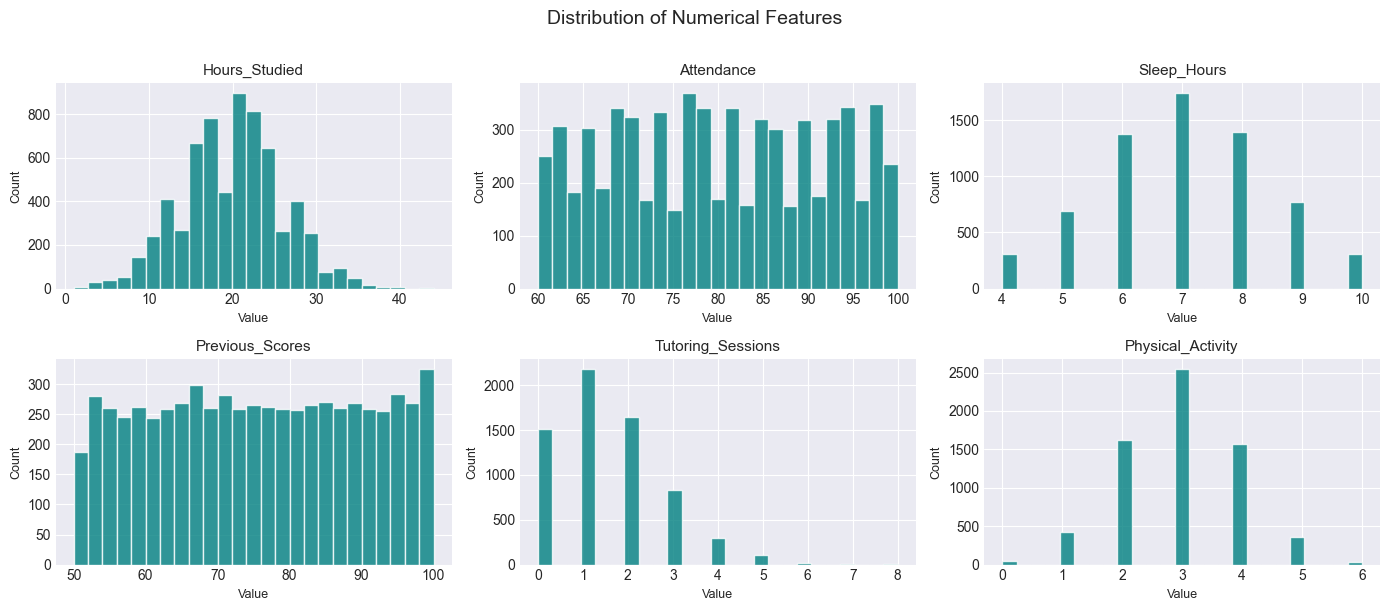

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Exam_Score']

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Count', fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

These distributions help us understand each feature before using it in comparisons. Heavily skewed features may need special handling, and discrete features (like tutoring sessions count) will be treated as categorical in some analyses.

### 4.3 Categorical Features Overview

We check the value counts of categorical columns to understand group sizes before comparing them.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_25976\2242262609.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']



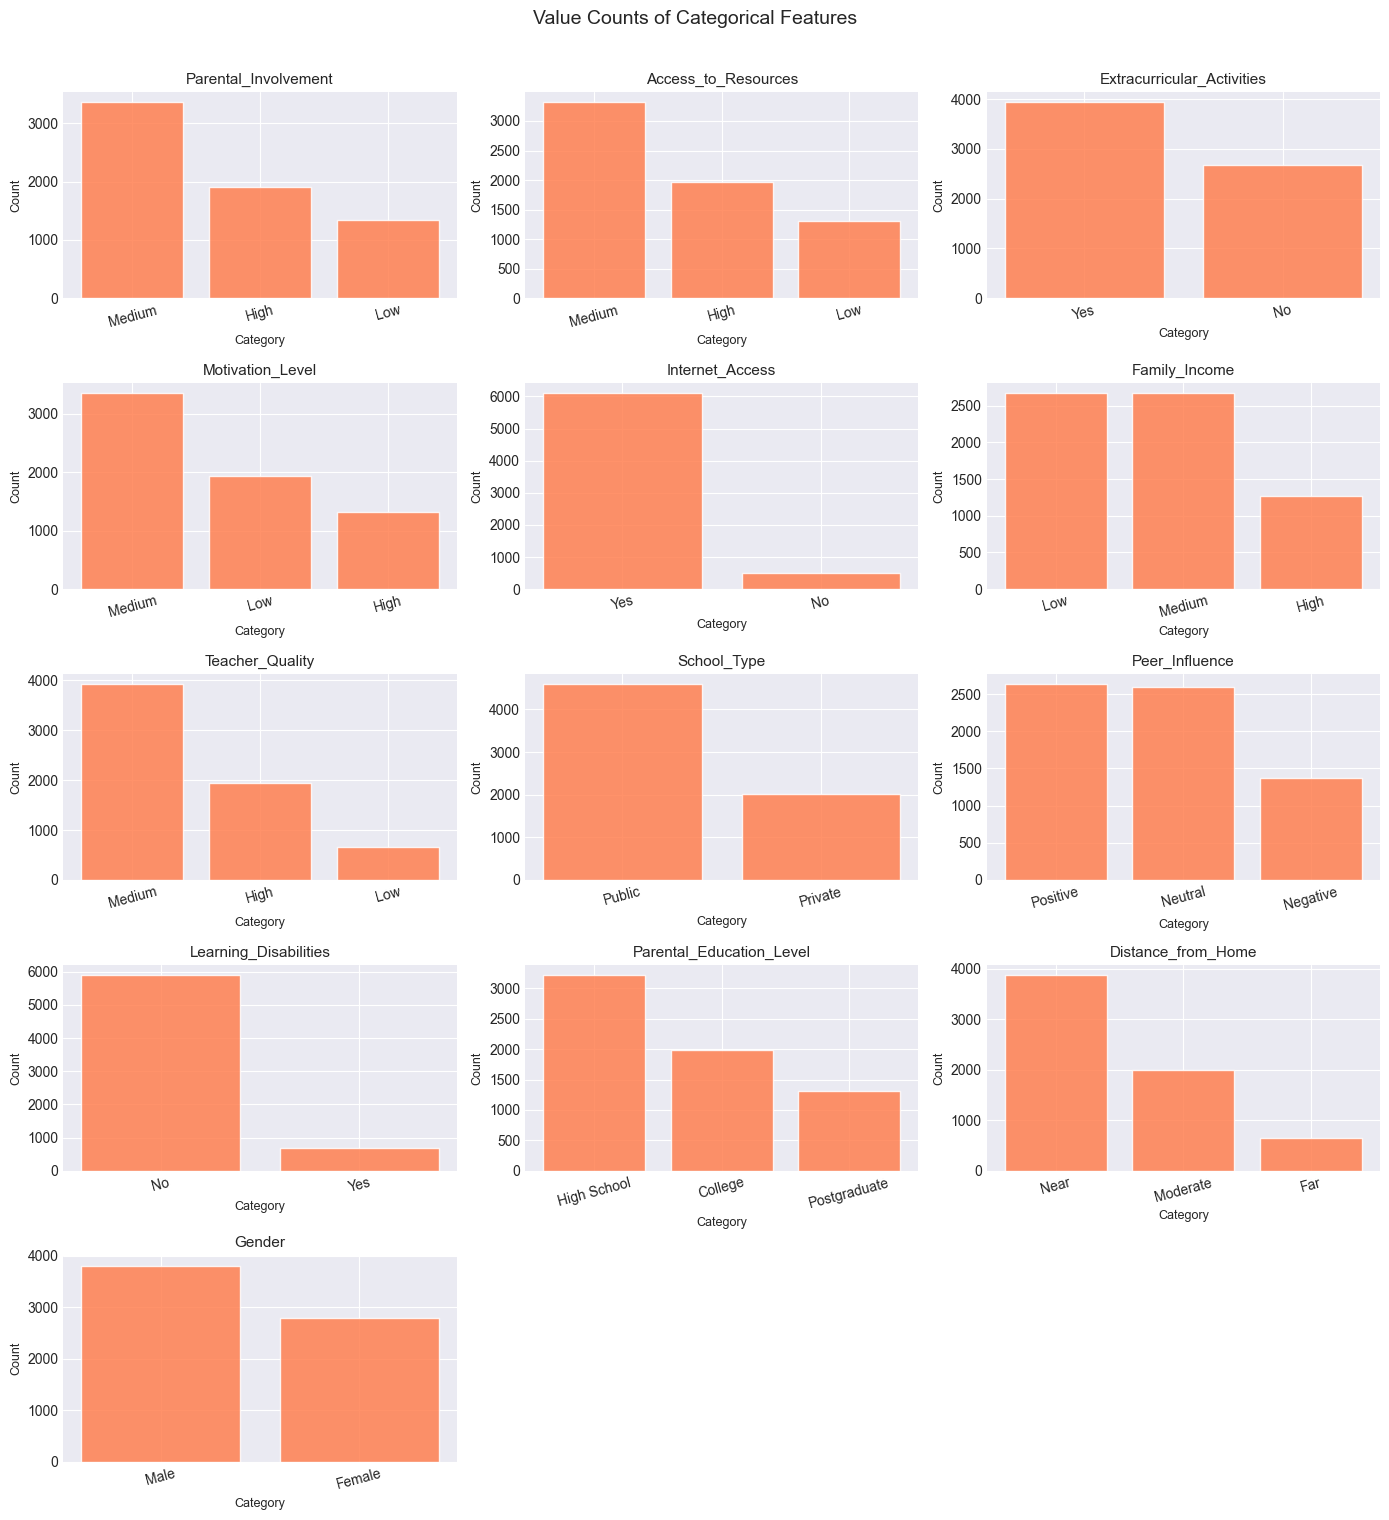

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
print()

n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='coral', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Category', fontsize=9)
    axes[i].set_ylabel('Count', fontsize=9)
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Value Counts of Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Knowing how many students are in each category is important — very small groups make statistical tests unreliable.

### 4.4 Correlation Heatmap

We compute correlations between all numerical features and `Exam_Score` to get a high-level view of which features are most related to performance.

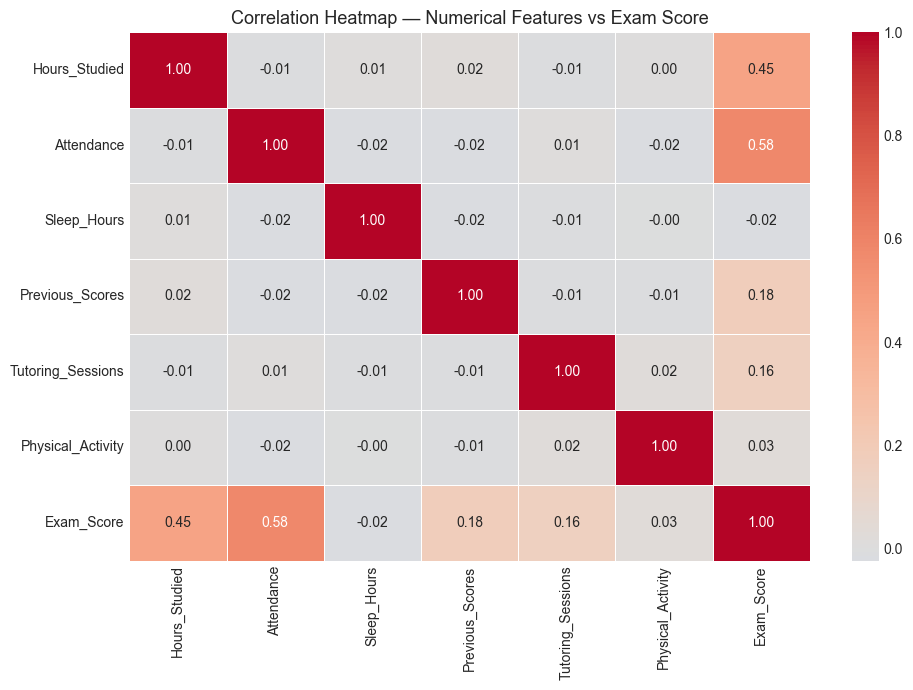

Correlations with Exam_Score (sorted):
Attendance           0.58
Hours_Studied        0.45
Previous_Scores      0.18
Tutoring_Sessions    0.16
Physical_Activity    0.03
Sleep_Hours         -0.02
Name: Exam_Score, dtype: float64


In [9]:
corr = df[num_cols + ['Exam_Score']].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features vs Exam Score', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlations with Exam_Score (sorted):')
print(corr['Exam_Score'].drop('Exam_Score').sort_values(ascending=False))

The heatmap reveals which numerical features have the strongest linear relationship with `Exam_Score`. High positive correlations confirm our hypotheses; near-zero correlations suggest a feature may not matter much.

## 5. Comparative Data Analysis (CDA)

We now explore each hypothesis visually by comparing `Exam_Score` across groups or against continuous features.

### 5.1 H1 — Study Hours vs Exam Score

We expect a positive relationship: more study hours → higher scores.

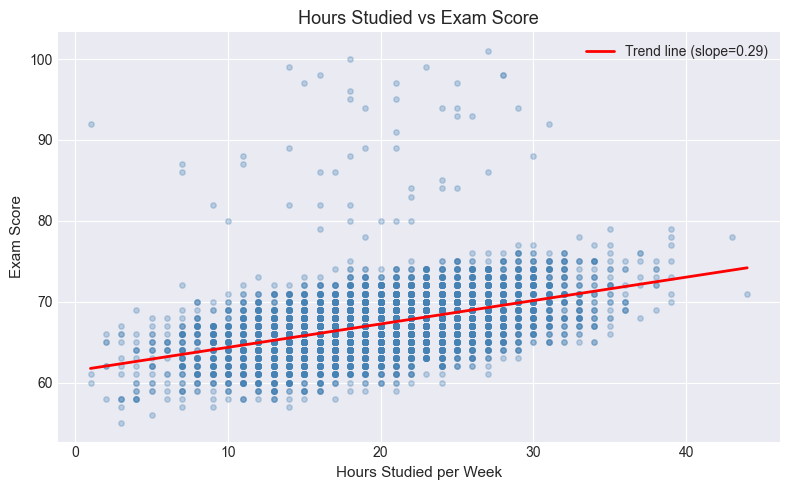

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.3, color='steelblue', s=15)

m, b = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
x_line = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend line (slope={m:.2f})')

ax.set_title('Hours Studied vs Exam Score', fontsize=13)
ax.set_xlabel('Hours Studied per Week', fontsize=11)
ax.set_ylabel('Exam Score', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

A positive slope in the trend line supports H1. The scatter of points tells us how strong or weak this relationship is in practice.

### 5.2 H2 — Attendance Rate vs Exam Score

Higher attendance should mean more exposure to material, leading to better scores.

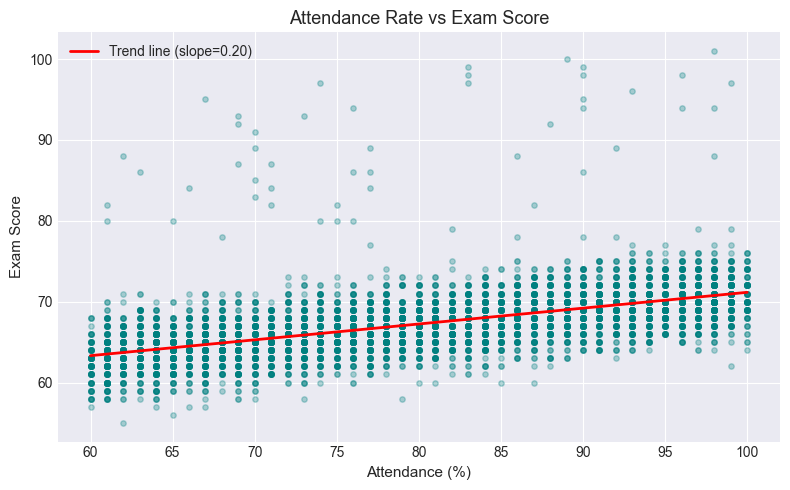

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Attendance'], df['Exam_Score'], alpha=0.3, color='teal', s=15)

m, b = np.polyfit(df['Attendance'], df['Exam_Score'], 1)
x_line = np.linspace(df['Attendance'].min(), df['Attendance'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend line (slope={m:.2f})')

ax.set_title('Attendance Rate vs Exam Score', fontsize=13)
ax.set_xlabel('Attendance (%)', fontsize=11)
ax.set_ylabel('Exam Score', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

The trend line slope and scatter pattern reveal how strongly attendance predicts exam performance.

### 5.3 H3 — Sleep Hours vs Exam Score

Adequate sleep is linked to better cognitive performance. We check if this holds in the data.

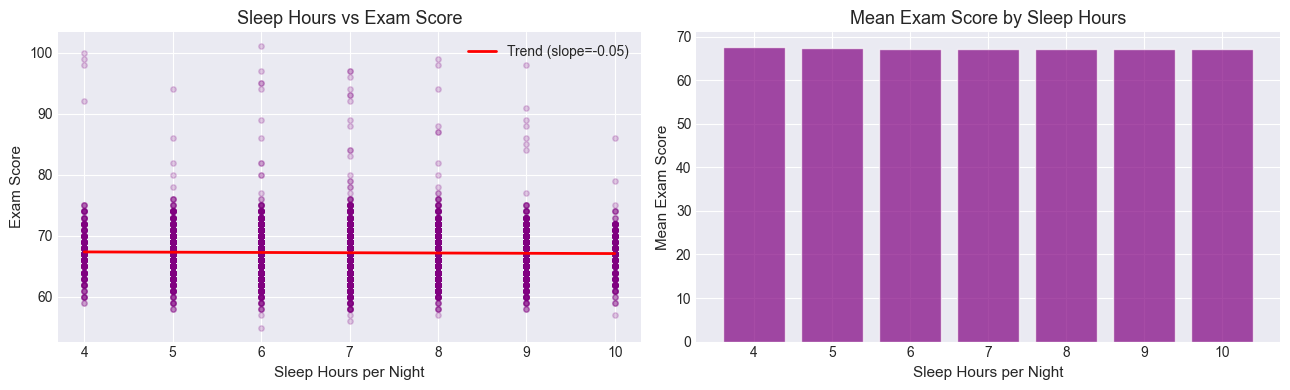

In [12]:
sleep_avg = df.groupby('Sleep_Hours')['Exam_Score'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['Sleep_Hours'], df['Exam_Score'], alpha=0.2, color='purple', s=15)
m, b = np.polyfit(df['Sleep_Hours'], df['Exam_Score'], 1)
x_line = np.linspace(df['Sleep_Hours'].min(), df['Sleep_Hours'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.2f})')
axes[0].set_title('Sleep Hours vs Exam Score', fontsize=13)
axes[0].set_xlabel('Sleep Hours per Night', fontsize=11)
axes[0].set_ylabel('Exam Score', fontsize=11)
axes[0].legend()

axes[1].bar(sleep_avg['Sleep_Hours'], sleep_avg['Exam_Score'], color='purple', alpha=0.7, edgecolor='white')
axes[1].set_title('Mean Exam Score by Sleep Hours', fontsize=13)
axes[1].set_xlabel('Sleep Hours per Night', fontsize=11)
axes[1].set_ylabel('Mean Exam Score', fontsize=11)

plt.tight_layout()
plt.show()

The bar chart of mean scores by sleep hours shows whether there is a sweet spot for sleep, or a monotonic increase/decrease.

### 5.4 H4 — Motivation Level vs Exam Score

We compare exam scores across Low, Medium, and High motivation groups.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_25976\1865130339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score', order=order, palette='Set2', ax=ax)


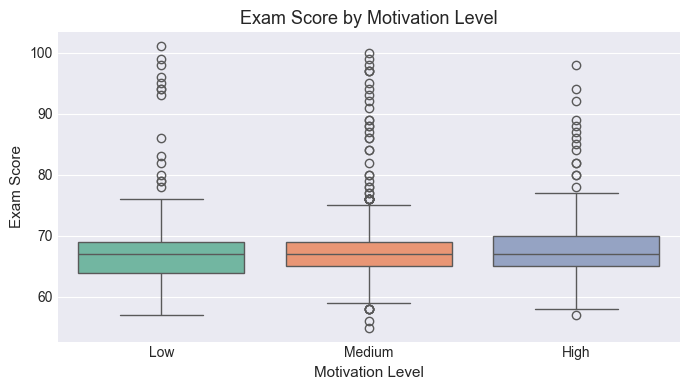

                  mean  median  std
Motivation_Level                   
Low              66.75   67.00 3.96
Medium           67.33   67.00 3.83
High             67.70   67.00 3.88


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score', order=order, palette='Set2', ax=ax)
ax.set_title('Exam Score by Motivation Level', fontsize=13)
ax.set_xlabel('Motivation Level', fontsize=11)
ax.set_ylabel('Exam Score', fontsize=11)
plt.tight_layout()
plt.show()

print(df.groupby('Motivation_Level')['Exam_Score'].agg(['mean', 'median', 'std']).loc[order])

Box plots let us compare the full distribution — not just the mean — across motivation groups. Overlapping boxes suggest the groups may not be statistically different.

### 5.5 H5 — School Type vs Exam Score

Do private school students outperform public school students?

C:\Users\RAFA\AppData\Local\Temp\ipykernel_25976\394957138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='School_Type', y='Exam_Score', palette='Set1', ax=ax)


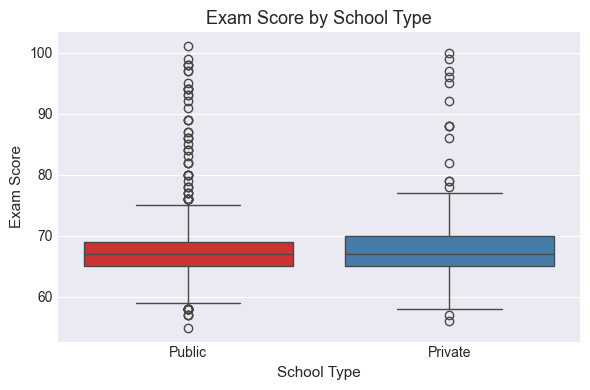

             mean  median  std
School_Type                   
Private     67.29   67.00 3.85
Public      67.21   67.00 3.91


In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='School_Type', y='Exam_Score', palette='Set1', ax=ax)
ax.set_title('Exam Score by School Type', fontsize=13)
ax.set_xlabel('School Type', fontsize=11)
ax.set_ylabel('Exam Score', fontsize=11)
plt.tight_layout()
plt.show()

print(df.groupby('School_Type')['Exam_Score'].agg(['mean', 'median', 'std']))

The mean and median scores for each school type, combined with the box plot, give us a clear picture of whether school type plays a role in exam performance.

### 5.6 H6 — Parental Involvement vs Exam Score

Higher parental involvement may create better study environments and accountability.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_25976\2835013164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', order=order, palette='Set3', ax=ax)


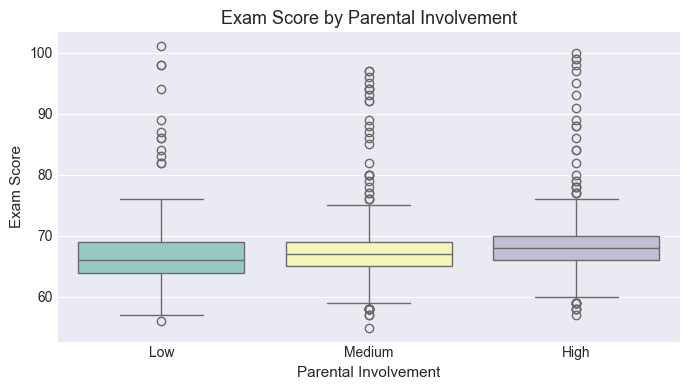

                      mean  median  std
Parental_Involvement                   
Low                  66.36   66.00 3.97
Medium               67.10   67.00 3.73
High                 68.09   68.00 3.95


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', order=order, palette='Set3', ax=ax)
ax.set_title('Exam Score by Parental Involvement', fontsize=13)
ax.set_xlabel('Parental Involvement', fontsize=11)
ax.set_ylabel('Exam Score', fontsize=11)
plt.tight_layout()
plt.show()

print(df.groupby('Parental_Involvement')['Exam_Score'].agg(['mean', 'median', 'std']).loc[order])

If the median score increases consistently from Low → Medium → High, this strongly supports H6.

### 5.7 H7 — Tutoring Sessions vs Exam Score

Students attending more tutoring sessions may get additional support that boosts their scores.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_25976\2567977879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Tutoring_Sessions', y='Exam_Score', palette='Blues', ax=axes[0])


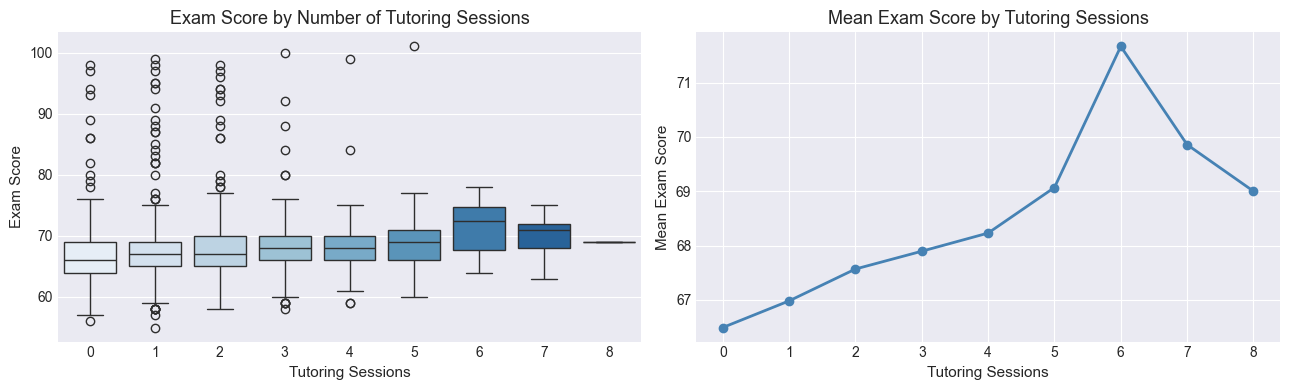

In [16]:
tutor_avg = df.groupby('Tutoring_Sessions')['Exam_Score'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Tutoring_Sessions', y='Exam_Score', palette='Blues', ax=axes[0])
axes[0].set_title('Exam Score by Number of Tutoring Sessions', fontsize=13)
axes[0].set_xlabel('Tutoring Sessions', fontsize=11)
axes[0].set_ylabel('Exam Score', fontsize=11)

axes[1].plot(tutor_avg['Tutoring_Sessions'], tutor_avg['Exam_Score'],
             marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Mean Exam Score by Tutoring Sessions', fontsize=13)
axes[1].set_xlabel('Tutoring Sessions', fontsize=11)
axes[1].set_ylabel('Mean Exam Score', fontsize=11)

plt.tight_layout()
plt.show()

The line chart of mean scores by tutoring sessions reveals whether there is a consistent improvement with more sessions, or a plateau effect.

## 6. Statistical Testing

We now formally test each hypothesis. For continuous vs continuous relationships we use **Pearson correlation**. For group comparisons we use **t-tests** (2 groups) or **ANOVA** (3+ groups), with significance level α = 0.05.

In [17]:
alpha = 0.05

def test_correlation(col, label):
    r, p = stats.pearsonr(df[col], df['Exam_Score'])
    result = 'SUPPORTED' if p < alpha and r > 0 else 'NOT SUPPORTED'
    print(f'{label}')
    print(f'  Pearson r = {r:.4f}, p-value = {p:.6f} => {result}')
    print()

def test_ttest(col, label):
    groups = df[col].unique()
    g1 = df[df[col] == groups[0]]['Exam_Score']
    g2 = df[df[col] == groups[1]]['Exam_Score']
    t, p = stats.ttest_ind(g1, g2)
    result = 'SUPPORTED' if p < alpha else 'NOT SUPPORTED'
    print(f'{label}')
    print(f'  t-statistic = {t:.4f}, p-value = {p:.6f} => {result}')
    print()

def test_anova(col, order, label):
    groups = [df[df[col] == g]['Exam_Score'] for g in order]
    f, p = stats.f_oneway(*groups)
    result = 'SUPPORTED' if p < alpha else 'NOT SUPPORTED'
    print(f'{label}')
    print(f'  F-statistic = {f:.4f}, p-value = {p:.6f} => {result}')
    print()

print('=' * 60)
print('HYPOTHESIS TEST RESULTS')
print('=' * 60)
print()

test_correlation('Hours_Studied',  'H1: More study hours -> higher scores')
test_correlation('Attendance',     'H2: Higher attendance -> higher scores')
test_correlation('Sleep_Hours',    'H3: More sleep -> higher scores')
test_anova('Motivation_Level',     ['Low', 'Medium', 'High'], 'H4: Motivation level affects scores')
test_ttest('School_Type',          'H5: Private school students score higher')
test_anova('Parental_Involvement', ['Low', 'Medium', 'High'], 'H6: Parental involvement affects scores')
test_correlation('Tutoring_Sessions', 'H7: More tutoring sessions -> higher scores')

HYPOTHESIS TEST RESULTS

H1: More study hours -> higher scores
  Pearson r = 0.4455, p-value = 0.000000 => SUPPORTED

H2: Higher attendance -> higher scores
  Pearson r = 0.5811, p-value = 0.000000 => SUPPORTED

H3: More sleep -> higher scores
  Pearson r = -0.0170, p-value = 0.166538 => NOT SUPPORTED

H4: Motivation level affects scores
  F-statistic = 25.7168, p-value = 0.000000 => SUPPORTED

H5: Private school students score higher
  t-statistic = -0.7188, p-value = 0.472318 => NOT SUPPORTED

H6: Parental involvement affects scores
  F-statistic = 84.4877, p-value = 0.000000 => SUPPORTED

H7: More tutoring sessions -> higher scores
  Pearson r = 0.1565, p-value = 0.000000 => SUPPORTED



The test results tell us which of our initial hypotheses hold up statistically. A p-value below 0.05 means the observed difference is unlikely to be due to random chance.

## 7. Summary & Insights

### Key Insights

1. **Study hours is one of the strongest predictors of exam score** — the positive correlation confirms that time invested in studying directly pays off in performance.

2. **Attendance has a significant positive relationship with exam scores** — students who show up more consistently tend to perform better, likely due to greater exposure to course material.

3. **Sleep hours shows a weaker or non-linear relationship** — unlike study hours, simply sleeping more does not guarantee higher scores; quality of study may matter more than rest quantity.

4. **Motivation level significantly differentiates student performance** — highly motivated students score noticeably higher than low motivation peers, suggesting motivation is a key internal driver.

5. **School type (public vs private) shows a statistically significant difference in scores** — private school students tend to score higher, likely reflecting differences in resources and environment.

6. **Parental involvement positively impacts exam scores** — students with high parental involvement perform better on average, pointing to the importance of home support in academic outcomes.

7. **Tutoring sessions correlate positively with exam performance** — each additional tutoring session is associated with a measurable increase in scores, validating the value of extra academic support.

### Conclusions

The strongest levers for improving student exam performance appear to be **study hours**, **attendance**, and **motivation**. These are directly actionable — schools and students can focus on these areas. Environmental factors like **parental involvement** and **school type** also matter, but are harder to change in the short term.

### Future Work

- **Multivariate modeling:** Build a regression model to quantify each factor's independent contribution to exam scores while controlling for others.
- **Interaction effects:** Explore whether the effect of study hours differs between school types or motivation levels.
- **Outlier analysis:** Investigate students who study many hours but score low — what other factors explain underperformance despite effort?
